# Numerical Analysis of ODEs

In this notebook we will learn how to use the numerical tools offered by Python to analyze systems of differential equations. 

We will start our exploration from the integration of a system of ordinary differential equations (ODEs, in short). Our motivating example will be the SIR model, a simple system of non-linear differential equations. All methods we will be employing are extremely general, though, and can be adatapted to investigate a large class of models relevant to Systems Biology. 

We importing a few libraries.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

We also want matplolib to generate its plot right into the notebook. This behavior is enabled with the magic function below:

In [2]:
%matplotlib inline

The default size of matplotlib graphs is rather small. We can enlarge them with the following setting:

In [3]:
mpl.rc('figure', figsize=(14,7))

Finally, we need a function to integrate our ODE system. We import it from the *scipy* library:

In [4]:
from scipy.integrate import odeint

## Model Definition

We need to describe the SIR model to Python.

Here we introduce the `sir` function which:

  * receives as its first argument the population sizes (for S, I and R people);
  * receives as further arguments all the parameters of the model;
  * computes and returns the derivatives of the variables S, I and R.

In [5]:
def sir(pop, t, rb, rd, ri, rr, rs):
    s, i, r = pop

    return ( rb + rs*r - ri*s*i,
             ri*s*i - rr*i - rd*i,
             rr*i - rs*r )

Note that the `sir` function receives as input the time `t` at which the derivative has to be evaluated. In this specific case we don't need it, as the derivatives do not depend explicitly on time.

To setup numerical integration we fix the values of the parameters and the initial population sizes:

In [6]:
p0 = (990, 10, 0)
params = (3, .02, .0005, .05, 0.01)

We define an array of time points at which we want evaluate the model. Here we take the first 1000 days.

In [7]:
T = np.arange(1000)

We invoke the `odeint` numerical integrator with the following arguments:

  * the function describing the model;
  * the initial population sizes;
  * the time points for the simulation;
  * the model parameters.

In [8]:
P = odeint(sir, p0, T, params)

The output of this function is a matrix with:

  * as many rows as there are time points;
  * as many columns as there are variables.

In [9]:
P.shape

(1000, 3)

Looking at the numbers directly is not particularly informative. Let's plot them!

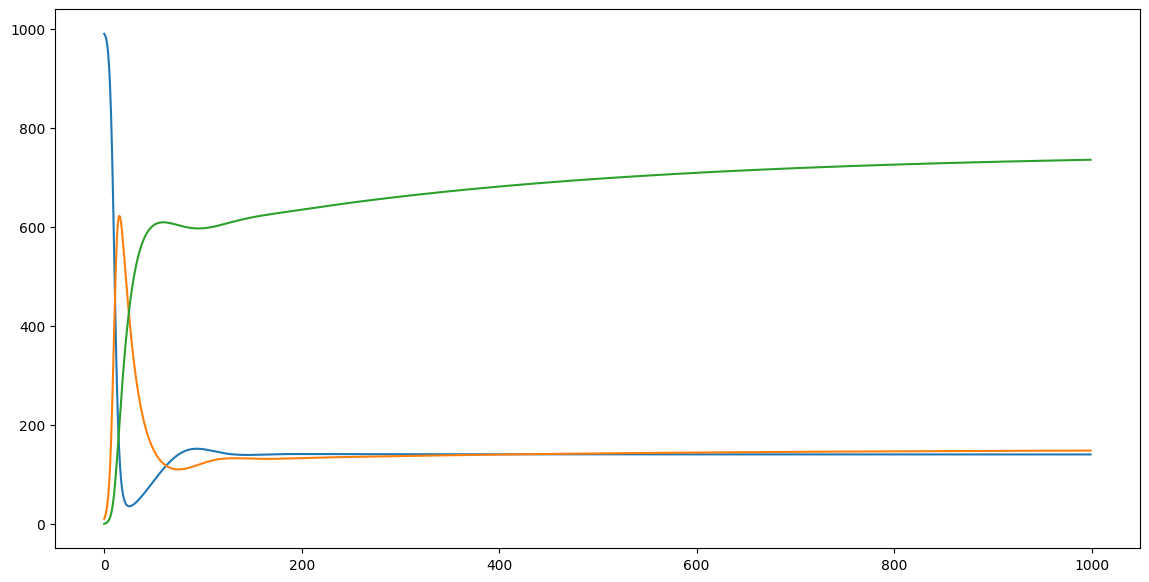

In [10]:
for i in range(3):
    plt.plot(T, P[:,i])
plt.show()

This plot almost corresponds to the illustration on the textbook, but there are a few things which are not right. First of all, there is no indication of which curve corresponds to which population. When we try to fathom them, it looks like the order of the colors do not match that of the textbook.

In the following snippet of code, we try to fix these issues. We customize the matplolib plot to add more information.

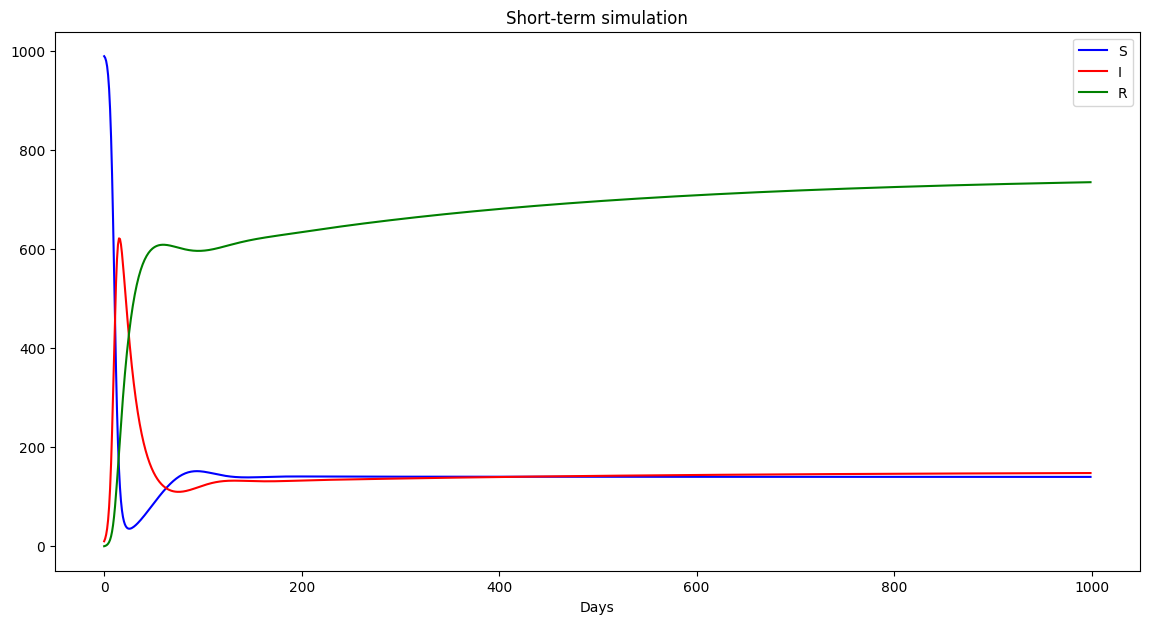

In [11]:
for i in range(3):
    plt.plot(T, P[:,i], color='brg'[i], label='SIR'[i])
plt.legend(loc='upper right')
plt.title('Short-term simulation')
plt.xlabel('Days')
plt.show()

## Interactive Exploration

In the previous sections we thought to specific conditions to simulate and we painstakingly wrote down the corresponding parameters. Each time we wanted to change something, we had to go back and to rewrite some code.

Wouldn't be nice to be able to change the parameters and immediately be able to see how they affact the system? Luckily, Jupyter got you covered with interactive widgets!

In [12]:
from ipywidgets import interact
import ipywidgets as widgets

To generate the plot, we need to gather all the relevant code into a single function `sir_interactive`.

We are going to parameterize such function on three variables:

  1. the total number of days in the simulation;
  2. $r_d$, that is the rate of death;
  3. $r_i$, the rate of infection.

In [13]:
@interact(
    days=widgets.IntSlider(min=100, max=1000, step=10, value=365),
    rd=widgets.FloatSlider(min=0, max=.5, step=.01, value=.02),
    ri=widgets.FloatSlider(min=.0001, max=.001, step=.0001, value=.0005, readout_format='.4f'))
def sir_interactive(days, rd, ri):
    p0 = (990, 10, 0)
    params = (3, rd, ri, .05, .01)
    T = np.arange(days)
    P = odeint(sir, p0, T, params)
    
    for i in range(3):
        plt.plot(T, P[:,i], color='brg'[i], label='SIR'[i])
        
    plt.legend(loc='upper right')
    plt.title('SIR simulation')
    plt.xlabel('Days')
    plt.show()

interactive(children=(IntSlider(value=365, description='days', max=1000, min=100, step=10), FloatSlider(value=…

# Stability Analysis

Judging from the plot above, it looks like the systems is reaching a steady state for $t >= 900$. Indeed, around day $1000$ in the simulation, the values of the variables seem to stop changing.

Is this a *stable* steady state?

We can get some indication (even though this is not a mathematical proof) by setting up a simulation. We take the population sizes at $t = 1000$ and we change them by adding / removing $20$ people from each pool.

In [14]:
p0_ss = P[-1,:] + np.array([20, -20, 20])

We start a new simulation using this perturbed values as initial conditions. We compute the evolution of the system for 50 more days.

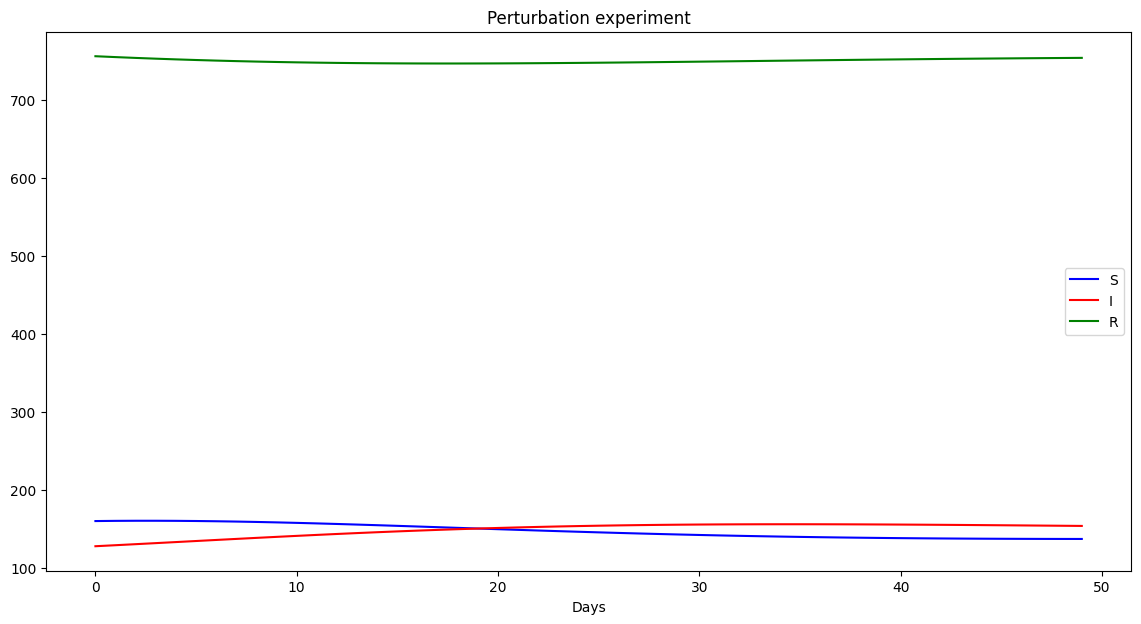

In [15]:
T2 = np.arange(50)
P_ss = odeint(sir, p0_ss, T2, params)

for i in range(3):
    plt.plot(T2, P_ss[:,i], color='brg'[i], label='SIR'[i])
plt.legend(loc='center right')
plt.title('Perturbation experiment')
plt.xlabel('Days')
plt.show()

We check how close we have returned to the original state of the system by computing the ratio among the population sizes before and after the perturbation.

In [16]:
P[-1,:] / P_ss[-1,:]

array([1.02130858, 0.96102029, 0.97625196])

The ratios are not exactly one, but they are close enough. This is an indication (but again, **not** a proof) that this could be a stable steady state.

## Linear Systems

Linear ODE systems provide an even simpler path for assessing the stability of a steady state: the study of *eigenvalues*.

The first example we are going to consider is the following model:

\begin{align*}
\dot{x} & = -6y - 3x \\
\dot{y} & = 2x + y
\end{align*}

We can represent it in matrix form by using the following defintion of $A$:

In [17]:
A = np.array([
        [-3, -6],
        [ 2, 1],
    ])

*Scipy* provides a function for computing the eigenvalues of matrices which is called `eigvals`. We import it and put it to the test.

In [18]:
from scipy.linalg import eigvals

In [19]:
eigvals(A)

array([-1.+2.82842712j, -1.-2.82842712j])

We observe that a $2 \times 2$ matrix has exactly $2$ eigenvalues, both of which are complex numbers. They are  defined as the sum of a *real* part (the first number) and an *immaginary* part (the second number, followed by a "j" label).

Theory tells us:

> If any of the eigenvalues has a positive real part, even if it is just one out of three dozen or so eigenvalues, the system is locally unstable. For stability, all real parts have to be negative.

In our example, all real parts are negative. We have stability!

To double check this result, let's plot the trajectory of the system starting from the initial condition $x = 6, y = 6$.

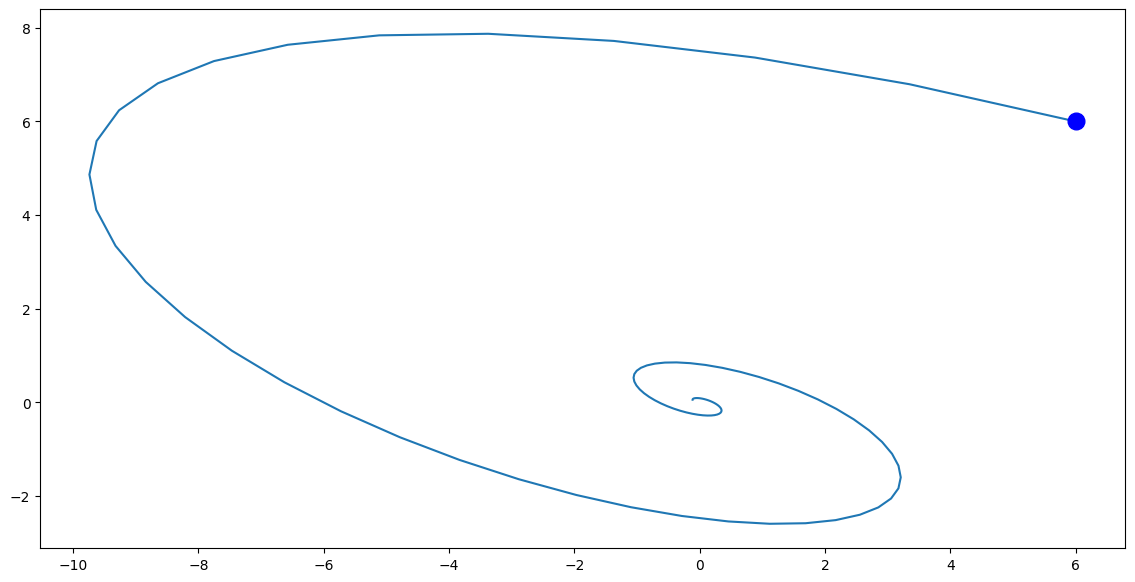

In [20]:
def model1(vs, t):
    return A.dot(vs)

ts = np.linspace(0, 5, 100)
vs = odeint(model1, (6, 6), ts)

plt.plot(vs[:,0], vs[:,1])
plt.plot(6, 6, "bo", markersize=12)  # initial condition
plt.show()

The system converges to the *stable* steady state at $x = 0$, $y = 0$.

Let's turn our attention to a different model.

\begin{align*}
\dot{x} & = x + 2y \\
\dot{y} & = x + 4y
\end{align*}

The eigenvalues are:

In [21]:
B = np.array([
        [ 1, 2],
        [ 1, 4],
    ])
eigvals(B)

array([0.43844719+0.j, 4.56155281+0.j])

Both real parts are positive. We conclude that the system is locally unstable.

Indeed, by numerical integration we can show that $x = 0, y = 0$ is a steady state.

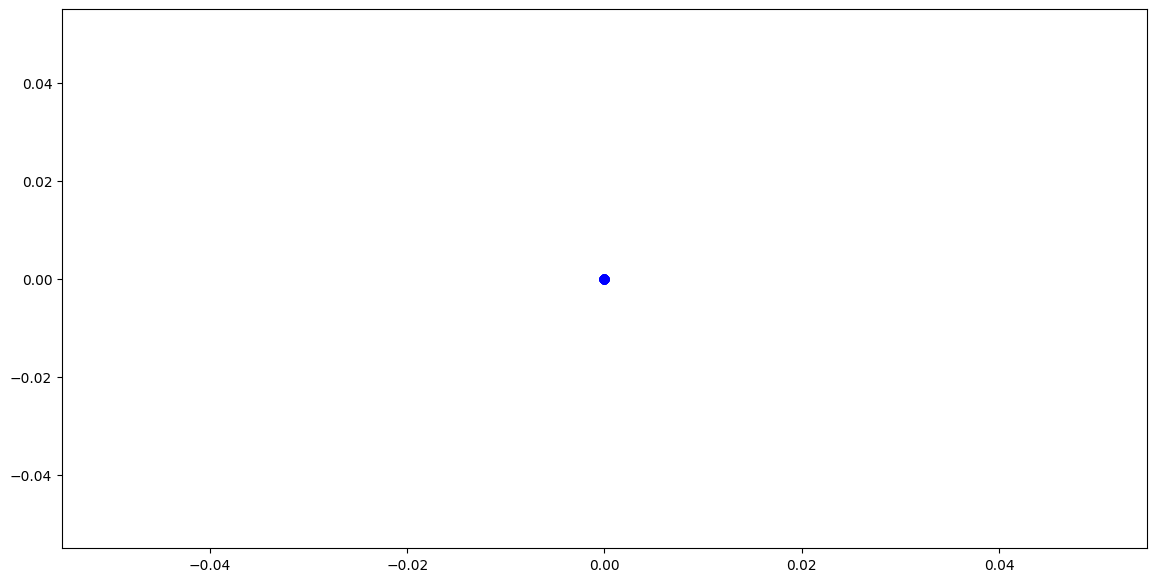

In [22]:
def model2(vs, t):
    return B.dot(vs)

ts = np.linspace(0, 5, 100)
vs = odeint(model2, (0, 0), ts)

plt.plot(vs[:,0], vs[:,1], "bo")
plt.show()

As soon a we change the coordinates, even by a small amount, the system moves away from the steady state.

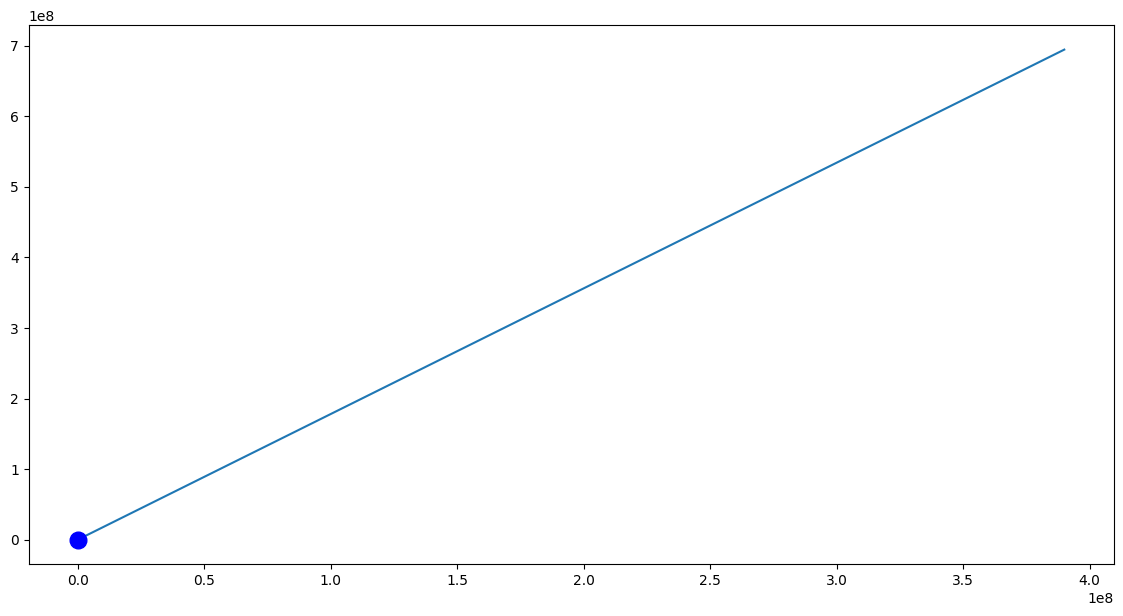

In [23]:
ts = np.linspace(0, 5, 100)
vs = odeint(model2, (0, 0.1), ts)

plt.plot(vs[:,0], vs[:,1])
plt.plot(0, 0, "bo", markersize=12)
plt.show()

# Monte Carlo Simulations

Up to this point we have been studying deterministic systems. As long as we start our simulations from the same initial conditions, the behavior we observe is always the same.

Monte Carlo approaches, on the other hand, investigate the effects of natural variability as encountered in practical settings. Going back to the *SIR* model, we might want to assess the role of inter-individual variability. Specifically, different people might exhibit varying levels of resistance to infection and overall survival once infected. 

We are going to model such variability by letting the parameters $r_I$ and $r_D$ change within some given bounds. We let:

  * $r_I$ range in $[0.0002, 0.001]$
  * $r_D$ range in $[0, 0.04]$

In [24]:
def sir_mc(n, days):
    p0 = (990, 10, 0)
    rI = 2e-4 + np.random.rand(n) * .0008
    rD = np.random.rand(n) * .04
    
    for i in range(n):
        params = (3., rD[i], rI[i], .05, .01)
        T = np.arange(days)
        P = odeint(sir, p0, T, params)
        plt.plot(T, P[:,0], color='b')
        
    plt.show()

Each simulation starts with a random choice of values for $r_I$ and $r_D$. The evolution of the model is then computed by numerical integration over a period of 365 days.

In total, we will perform 10 independent simulations. This is a rather small number, but here we chose it to make the plots easier to inspect. In practice, we would run millions of simulations to allow for reliable statistical inference.

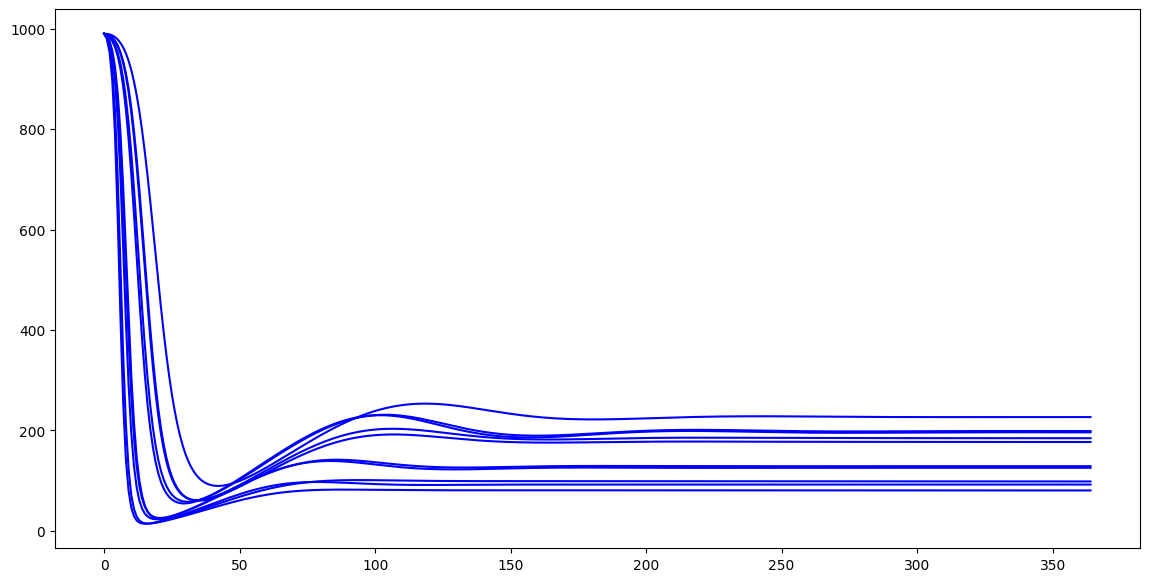

In [25]:
sir_mc(10, 365)